In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier



# Caricare i dati dal CSV
file_path = 'Data/features_3_sec.csv'
data = pd.read_csv(file_path)

# Stampa i nomi delle colonne per verificare
#print("Colonne nel DataFrame:", data.columns)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = data['label']  # Etichette

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]


senza nulla

In [2]:

model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)

    # Calcolare metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
print(f'Accuratezza: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'F2-score: {f2:.4f}')
print('------------------------------------------------------------')

Accuratezza: 0.8178
Precision: 0.8174
Recall: 0.8177
F1-score: 0.8146
F2-score: 0.8159
------------------------------------------------------------


In [3]:
for scaler in scalers:

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Definizione del modello di Logistic Regression
    model = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
    model.fit(X_train, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'Scaler: {scaler.__class__.__name__}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    print('------------------------------------------------------------')

Scaler: RobustScaler
Accuratezza: 0.8173
Precision: 0.8168
Recall: 0.8172
F1-score: 0.8143
F2-score: 0.8154
------------------------------------------------------------


KeyboardInterrupt: 

In [14]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [50, 100],  # Numero di alberi nella foresta
    'max_depth': [10, 20, 30],  # Profondità massima di ciascun albero
    'min_samples_split': [2, 5, 10],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1, 2, 4],    # Minimo numero di campioni richiesti in una foglia
    'bootstrap': [True, False]        # Uso del bootstrap per campionare i dati
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuratezza: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Migliori iperparametri trovati: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuratezza: 0.7700
Precision: 0.7707
Recall: 0.7829
F1-score: 0.7705


In [9]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [500,550],  # Numero di alberi nella foresta
    'max_depth': [35],  # Profondità massima di ciascun albero
    'min_samples_split': [2],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1],    # Minimo numero di campioni richiesti in una foglia
    'bootstrap': [False]        # Uso del bootstrap per campionare i dati
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuratezza: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Migliori iperparametri trovati: {'bootstrap': False, 'max_depth': 35, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 550}
Accuratezza: 0.9079
Precision: 0.9078
Recall: 0.9079
F1-score: 0.9072


Accuratezza per ogni fold: [0.9049049049049049, 0.9019019019019019, 0.9029029029029029, 0.8988988988988988, 0.8958958958958959, 0.9119119119119119, 0.9029029029029029, 0.8978978978978979, 0.8918918918918919, 0.8948948948948949]
Accuratezza media dopo K-Fold: 0.9004

Feature selezionate dal Lasso: ['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_mean', 'perceptr_var', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var'

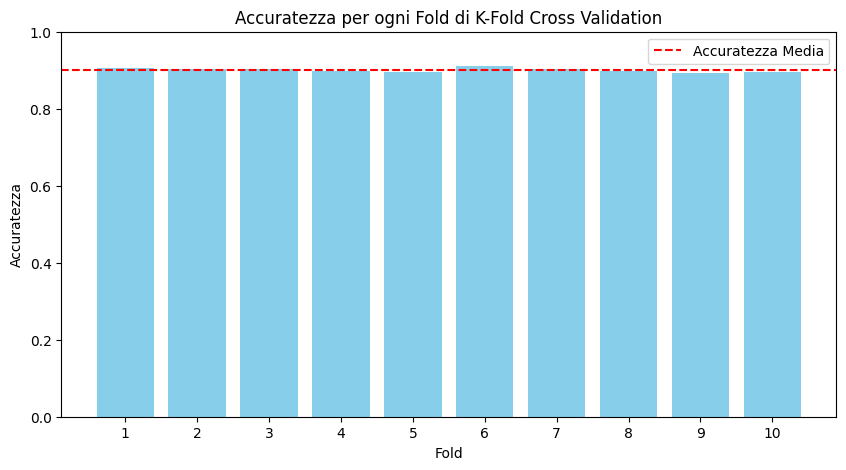

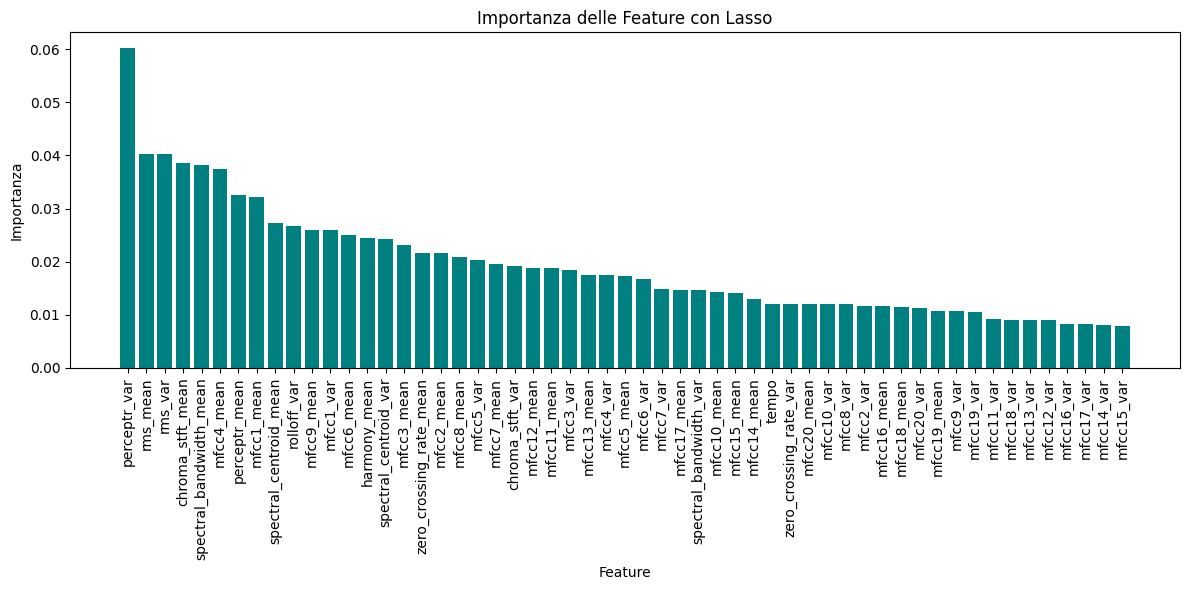

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_3_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
importances_dict = {}  # Dizionario per tracciare le importanze delle feature selezionate

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Random Forest sulle feature selezionate
    model = RandomForestClassifier(bootstrap=False, max_depth=35, min_samples_leaf=1, min_samples_split=2, n_estimators=300)
    model.fit(X_train_selected, y_train)

    # Calcolare l'importanza delle feature
    importances = model.feature_importances_
    
    # Salvare le importanze solo per le feature selezionate
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]  # Ottieni il nome della feature
        if feature_name in importances_dict:
            importances_dict[feature_name].append(importances[i])
        else:
            importances_dict[feature_name] = [importances[i]]

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print("Indice di feature selezionate:",(selected_features))
print("Numero di feature selezionate:", len(selected_feature_names))

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature con Lasso')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
